In [1]:
from ucimlrepo import fetch_ucirepo 
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from sklearn.model_selection import (train_test_split, learning_curve, StratifiedKFold)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, f1_score, roc_auc_score, confusion_matrix)
from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score, recall_score
import os
import ssl

# Desactivar la verificación estricta de certificados SSL localmente
if not os.environ.get("PYTHONHTTPSVERIFY", "") and getattr(
    ssl, "_create_unverified_context", None
):
    ssl._create_default_https_context = ssl._create_unverified_context
warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")


# Esto obliga a Plotly a usar Kaleido y dejar la imagen estática en el Notebook
pio.renderers.default = "png"


In [2]:
# fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# data (as pandas dataframes)
df = breast_cancer_wisconsin_diagnostic.data.original
df.head()

,ID,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis
0,842302,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,842517,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,84300903,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,84348301,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,84358402,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


A continuación, preparamos los datos de forma tal que podamos trabajar con las variables numéricas importantes, es decir, eliminamos la columna "id", la cual no aporta a nuestro modelo de clasificación.

Por otro lado, fijamos nuestro target (variable objetivo) "diagnosis" y dejamos a las demás variables como predictoras.

Finalmente, optaremos por transformar la variable categórica objetivo ("id") en una variable binaria en donde "Maligno = 0" y "Benigno = 1".

In [3]:
df = breast_cancer_wisconsin_diagnostic.data.original
df = df.drop(columns=["ID"])

X      = df.drop(columns=["Diagnosis"])
y      = (df["Diagnosis"] == "M").astype(int)
labels = df["Diagnosis"]

Ahora bien, haremos PCA para reducir la dimensionalidad del dataset, pues con 32 variables es bastante difícil observar y/o graficar la información. De esta forma, se crean nuevas componentes basadas en las anteriores para comprenderla mejor.

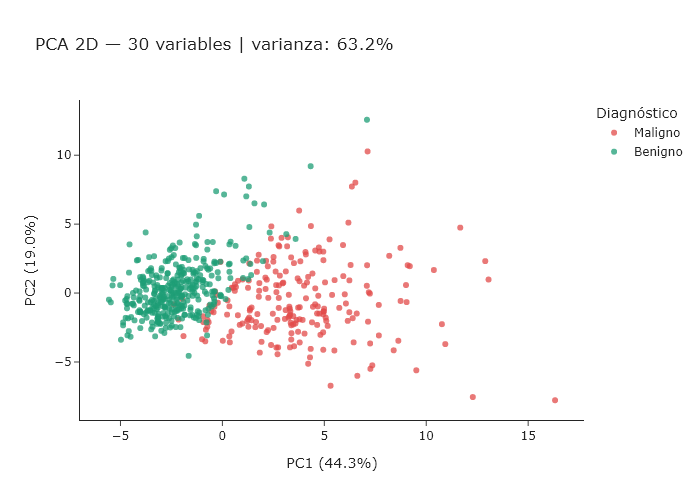

In [4]:
scaler_viz = StandardScaler()
X_sc_all   = scaler_viz.fit_transform(X)

pca2_full  = PCA(n_components=2, random_state=42)
coords2_f  = pca2_full.fit_transform(X_sc_all)
var2_f     = pca2_full.explained_variance_ratio_ * 100

df_2d_full = pd.DataFrame({
    "PC1":        coords2_f[:, 0],
    "PC2":        coords2_f[:, 1],
    "Diagnóstico": labels.map({"M": "Maligno", "B": "Benigno"})
})

fig = px.scatter(
    df_2d_full, x="PC1", y="PC2", color="Diagnóstico",
    color_discrete_map={"Maligno": "#E24B4A", "Benigno": "#1D9E75"},
    labels={"PC1": f"PC1 ({var2_f[0]:.1f}%)", "PC2": f"PC2 ({var2_f[1]:.1f}%)"},
    title=f"PCA 2D — 30 variables | varianza: {var2_f.sum():.1f}%",
    opacity=0.75, template="simple_white"
)
fig.update_traces(marker=dict(size=6))
fig.show()

La separación observada en el PCA sugiere que las variables tienen capacidad discriminante entre tumores benignos y malignos. Esto indica que podrían ser útiles para entrenar un modelo de clasificación efectivo para la detección de cáncer de mama, aunque esto debemos validarlo para estar más seguros.

Veamos, por otro lado, una reducción de dimensiones mediante PCA en el cual eliminemos redundancia, es decir, eliminar una de aquellas variables cuya correlación supera el 95%, pues cuando estos valores son tan altos, estamos ante la presencia de dos variables que tratan de explicar, en esencia, lo mismo.

Variables eliminadas (corr > 0.97): ['perimeter1', 'area1', 'perimeter2', 'perimeter3', 'area3']
  Original: 30 variables  →  Reducido: 25 variables


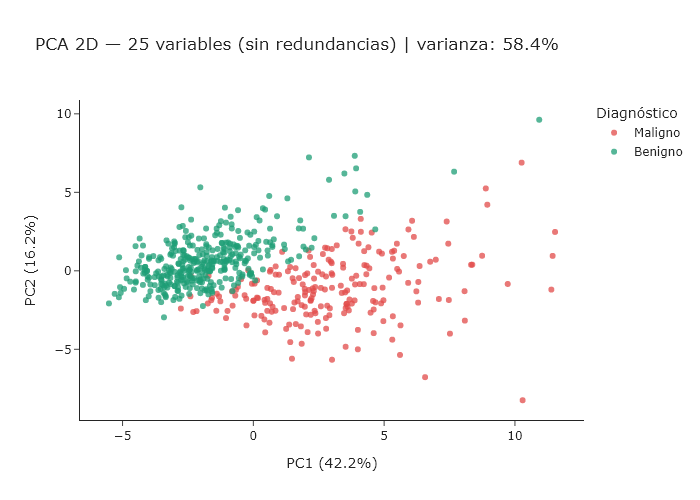

In [5]:
corr_matrix = X.corr().abs()
upper       = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop     = [col for col in upper.columns if any(upper[col] > 0.97)]

print(f"Variables eliminadas (corr > 0.97): {to_drop}")
print(f"  Original: {X.shape[1]} variables  →  Reducido: {X.shape[1] - len(to_drop)} variables")

X_reduced    = X.drop(columns=to_drop)
X_sc_reduced = StandardScaler().fit_transform(X_reduced)

pca2_red   = PCA(n_components=2, random_state=42)
coords2_r  = pca2_red.fit_transform(X_sc_reduced)
var2_r     = pca2_red.explained_variance_ratio_ * 100

df_2d_red  = pd.DataFrame({
    "PC1":        coords2_r[:, 0],
    "PC2":        coords2_r[:, 1],
    "Diagnóstico": labels.map({"M": "Maligno", "B": "Benigno"})
})

fig = px.scatter(
    df_2d_red, x="PC1", y="PC2", color="Diagnóstico",
    color_discrete_map={"Maligno": "#E24B4A", "Benigno": "#1D9E75"},
    labels={"PC1": f"PC1 ({var2_r[0]:.1f}%)", "PC2": f"PC2 ({var2_r[1]:.1f}%)"},
    title=f"PCA 2D — {X_reduced.shape[1]} variables (sin redundancias) | varianza: {var2_r.sum():.1f}%",
    opacity=0.75, template="simple_white"
)
fig.update_traces(marker=dict(size=6))
fig.show()

De la misma forma, la separación de los datos sigue siendo igual de buena que la anterior, sin embargo, observamos que la varianza acumulada de ambas difiere (aunque muy poco).

Esto indica que a mayor varianza acumulada se tiene una mejor conservación de los datos respecto al dataset original y viceversa, no obstante, al tener redundancias en la base de datos, esta varianza podría estar viéndose afectada o inflada en virtud de estas repeticiones de manera multivariada (no de manera univariada).

Por lo tanto, como la diferencia entre varianzas acumuladas es relativamente baja, escogeremos el PCA sin redundancias debido a que no se ve afectada por valores duplicados y su funcionamiento no es significativamente distinto al PCA con repeticiones.

Ahora bien, procedamos a hacer train/test/validation con valores 70/15/15 (con valores no redundantes) para posteriormente aplicar un modelo que mejor se adapte a los datos y, de esta manera, poder buscar la mejor clasificación de diagnósticos de la forma más confiable posible.

In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_reduced, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(f"\nSplit:")
print(f"  Train:      {len(X_train)} muestras ({len(X_train)/len(X_reduced):.0%})")
print(f"  Validation: {len(X_val)}  muestras ({len(X_val)/len(X_reduced):.0%})")
print(f"  Test:       {len(X_test)}  muestras ({len(X_test)/len(X_reduced):.0%})")


Split:
  Train:      398 muestras (70%)
  Validation: 85  muestras (15%)
  Test:       86  muestras (15%)


Ahora, procedemos a escalar los datos, pues en nuestro dataset existen valores demasiado grandes y otros que son demasiado pequeños, por tanto, habría sesgo. De esta forma, garantizamos trabajar bajo la misma escala y otorgando el mismo peso a cada variable.

In [7]:
scaler       = StandardScaler()
X_train_sc   = scaler.fit_transform(X_train)
X_val_sc     = scaler.transform(X_val)
X_test_sc    = scaler.transform(X_test)

A continuación, se compararán diferentes modelos de clasificación con el propósito de seleccionar aquel que mejor se ajuste a los datos. El objetivo principal es identificar el modelo con mayor capacidad para clasificar correctamente los tumores como malignos o benignos, priorizando el bienestar del paciente y reduciendo el riesgo de diagnósticos erróneos.

Primeramente, escogeremos los hiperparámetros óptimos para los modelos, pues aunque es mejor elegir valores altos, no siempre es conveniente debido al alto costo computacional. Además, si logramos que el modelo converja con valores relativamente pequeños, claramente será mejor.

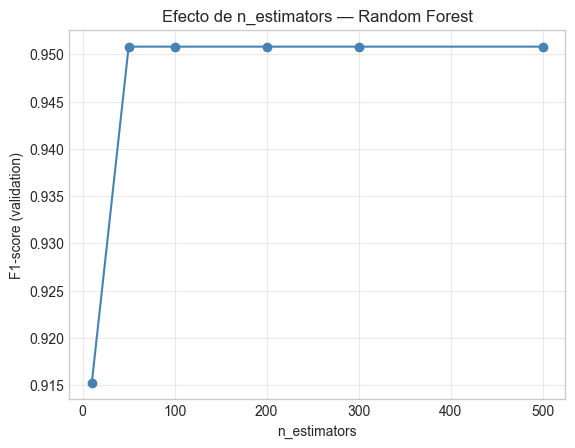

Mejor n_estimators: 50


In [8]:
n_vals   = [10, 50, 100, 200, 300, 500]
f1_vals  = []

for n in n_vals:
    m = RandomForestClassifier(n_estimators=n, random_state=42)
    m.fit(X_train_sc, y_train)
    f1_vals.append(f1_score(y_val, m.predict(X_val_sc)))

plt.plot(n_vals, f1_vals, "o-", color="steelblue")
plt.xlabel("n_estimators")
plt.ylabel("F1-score (validation)")
plt.title("Efecto de n_estimators — Random Forest")
plt.grid(alpha=0.4)
plt.show()
n_optimo = n_vals[f1_vals.index(max(f1_vals))]
print(f"Mejor n_estimators: {n_optimo}")

De esta forma, usaremos n_estimators = 50 para los modelos de random forest y Gradient Boosting.

Análogamente, trataremos de optimizar el número de iteraciones para el modelo de regresión logística, pues aunque podemos escoger números altos para mejorar el rendimiento, esto tiene alto costo computacional. De esta forma, determinaremos en qué iteración converge.

In [9]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_sc, y_train)

print(f"Iteraciones usadas: {model.n_iter_}")
print(f"Límite establecido: {model.max_iter}")

Iteraciones usadas: [20]
Límite establecido: 1000


Normalmente solemos escoger 1000 iteraciones, sin embargo, este número implica un alto costo computacional. En este caso observamos que sólo con 20 iteraciones el modelo funciona.


── Resultados en Validation ──────────────────────────────
Modelo                         F1     AUC   Recall
────────────────────────────────────────────────────
Logistic Regression        0.9508  0.9965   0.9062
Random Forest              0.9508  0.9947   0.9062
Gradient Boosting          0.9180  0.9935   0.8750
SVM (RBF)                  0.9841  0.9959   0.9688

★ Mejor modelo: SVM (RBF)


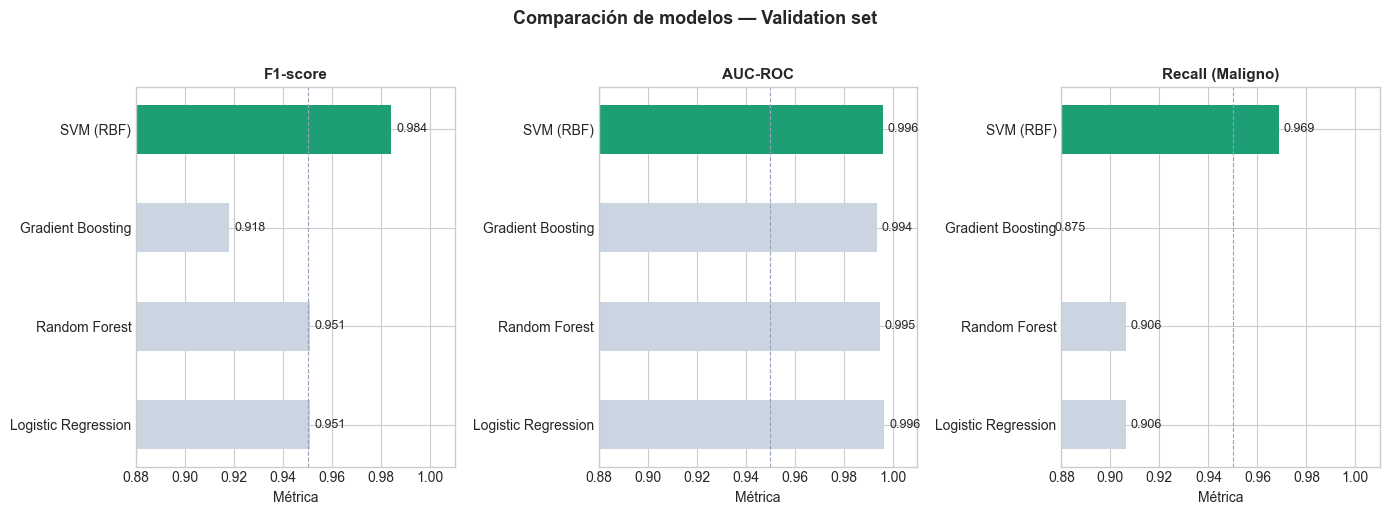

In [10]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=20, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=50, random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=50, random_state=42),
    "SVM (RBF)":           SVC(probability=True, random_state=42),
}

results = {}
print("\n── Resultados en Validation ──────────────────────────────")
print(f"{'Modelo':<25} {'F1':>7} {'AUC':>7} {'Recall':>8}")
print("─" * 52)

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_val_sc)
    y_prob = model.predict_proba(X_val_sc)[:, 1]

    f1     = f1_score(y_val, y_pred)
    auc    = roc_auc_score(y_val, y_prob)
    recall = classification_report(y_val, y_pred, output_dict=True)["1"]["recall"]

    results[name] = {"model": model, "f1": f1, "auc": auc, "recall": recall}
    print(f"{name:<25} {f1:>7.4f} {auc:>7.4f} {recall:>8.4f}")

# Mejor modelo por AUC
best_name  = max(results, key=lambda k: results[k]["f1"])
best_model = results[best_name]["model"]
print(f"\n★ Mejor modelo: {best_name}")

# Gráfico comparativo
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics   = ["f1", "auc", "recall"]
titles    = ["F1-score", "AUC-ROC", "Recall (Maligno)"]
colors    = ["#1D9E75" if n == best_name else "#CBD5E1" for n in results]

for ax, metric, title in zip(axes, metrics, titles):
    names  = list(results.keys())
    values = [results[n][metric] for n in names]
    bars   = ax.barh(names, values, color=colors, edgecolor="none", height=0.5)
    ax.set_xlim(0.88, 1.01)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Métrica")
    for bar, val in zip(bars, values):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f"{val:.3f}", va="center", fontsize=9)
    ax.axvline(0.95, color="#94A3B8", linewidth=0.8, linestyle="--")

plt.suptitle("Comparación de modelos — Validation set", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

Además, realicemos las curvas ROC con el propósito de determinar el desempeño de los modelos.

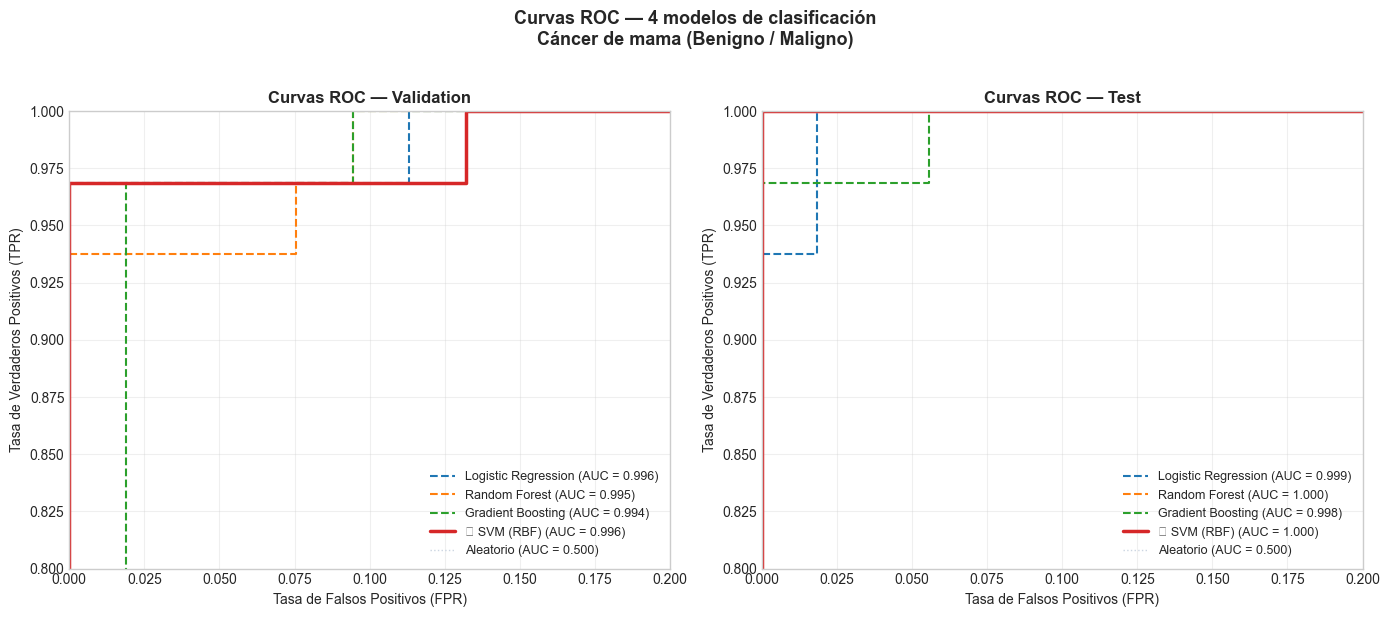

In [11]:
from sklearn.metrics import roc_curve, auc

# ── Curvas ROC — todos los modelos ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
titles = ["Validation", "Test"]
X_sets = [X_val_sc,  X_test_sc]
y_sets = [y_val,     y_test]

for ax, title, X_set, y_set in zip(axes, titles, X_sets, y_sets):

    for name in results.keys():
        model   = results[name]["model"]
        y_prob  = model.predict_proba(X_set)[:, 1]
        fpr, tpr, _ = roc_curve(y_set, y_prob)
        auc_val = auc(fpr, tpr)

        # Resaltar el mejor modelo
        es_mejor   = (name == best_name)
        linewidth  = 2.5 if es_mejor else 1.5
        linestyle  = "-"  if es_mejor else "--"
        label      = f"{'★ ' if es_mejor else ''}{name} (AUC = {auc_val:.3f})"

        ax.plot(fpr, tpr,
                linewidth=linewidth,
                linestyle=linestyle,
                label=label)

    # Línea de referencia (clasificador aleatorio)
    ax.plot([0, 1], [0, 1],
            color="#CBD5E1",
            linewidth=1,
            linestyle=":",
            label="Aleatorio (AUC = 0.500)")

    ax.set_title(f"Curvas ROC — {title}",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Tasa de Falsos Positivos (FPR)", fontsize=10)
    ax.set_ylabel("Tasa de Verdaderos Positivos (TPR)", fontsize=10)
    ax.legend(fontsize=9, loc="lower right")
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 0.20])
    ax.set_ylim([0.8, 1])

plt.suptitle("Curvas ROC — 4 modelos de clasificación\nCáncer de mama (Benigno / Maligno)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

Obtenemos que el mejor modelo es SVM, pues su "F1 score" y su "Recall" son superiores a los demás, mientras que su "AUC" es ligeramente menor que la regresión logística.

De esta manera, estamos garantizando que la clasificación de los tumores es más confiable en este modelo en comparación a los demás.

De aquí, construiremos las curvas de entrenamiento para AUC, F1 y Recall, pues de esta forma estaremos observando la evolución del desempeño del modelo durante el entrenamiento.

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def plot_learning_curve_metric(model, X, y, scoring, metric_name, ylim=(0.84, 1.02)):
    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )

    tr_mean = train_scores.mean(axis=1)
    tr_std  = train_scores.std(axis=1)
    v_mean  = val_scores.mean(axis=1)
    v_std   = val_scores.std(axis=1)

    fig, ax = plt.subplots(figsize=(9, 5))

    ax.fill_between(
        train_sizes,
        tr_mean - tr_std,
        tr_mean + tr_std,
        alpha=0.12,
        color="#1D9E75"
    )

    ax.fill_between(
        train_sizes,
        v_mean - v_std,
        v_mean + v_std,
        alpha=0.15,
        color="#D97706"
    )

    ax.plot(
        train_sizes,
        tr_mean,
        "o-",
        color="#1D9E75",
        linewidth=2,
        label="Train"
    )

    ax.plot(
        train_sizes,
        v_mean,
        "s--",
        color="#D97706",
        linewidth=2,
        label="Validación (5-fold CV)"
    )

    ax.set_title(
        f"Curvas de entrenamiento — {best_name} | {metric_name}",
        fontsize=13,
        fontweight="bold"
    )

    ax.set_xlabel("Tamaño del conjunto de entrenamiento (muestras)", fontsize=11)
    ax.set_ylabel(metric_name, fontsize=11)
    ax.set_ylim(*ylim)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.4)

    plt.tight_layout()
    plt.show()

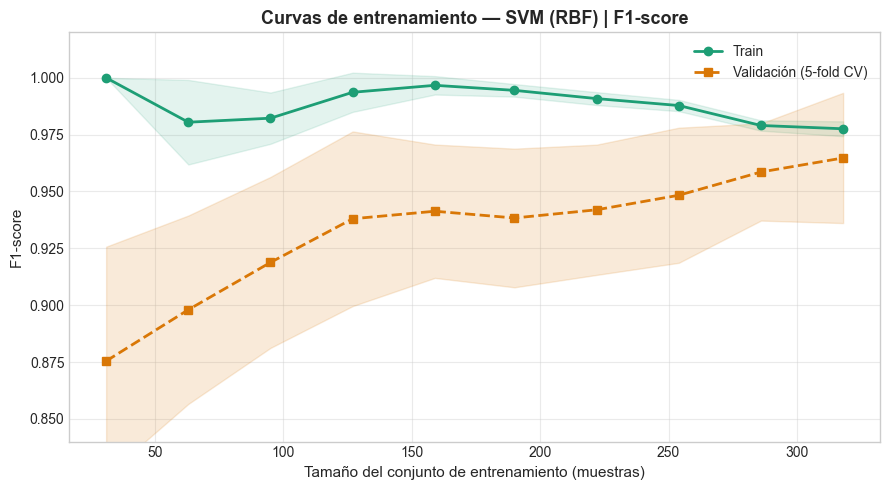

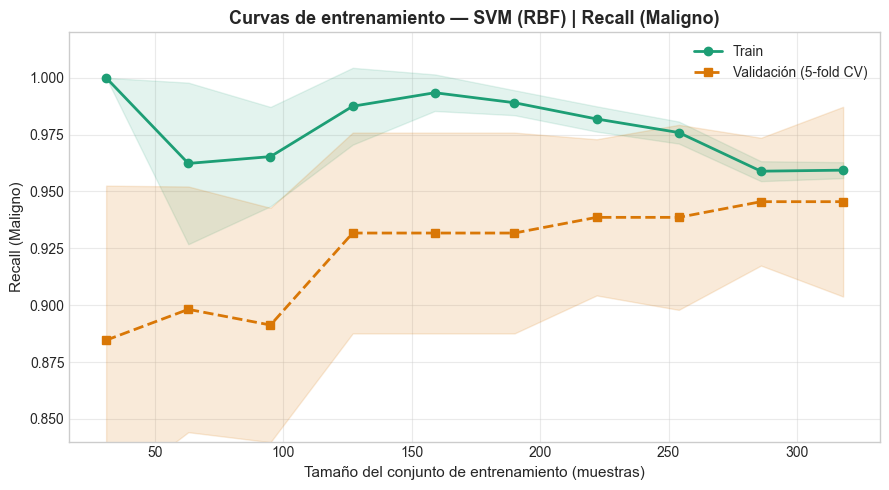

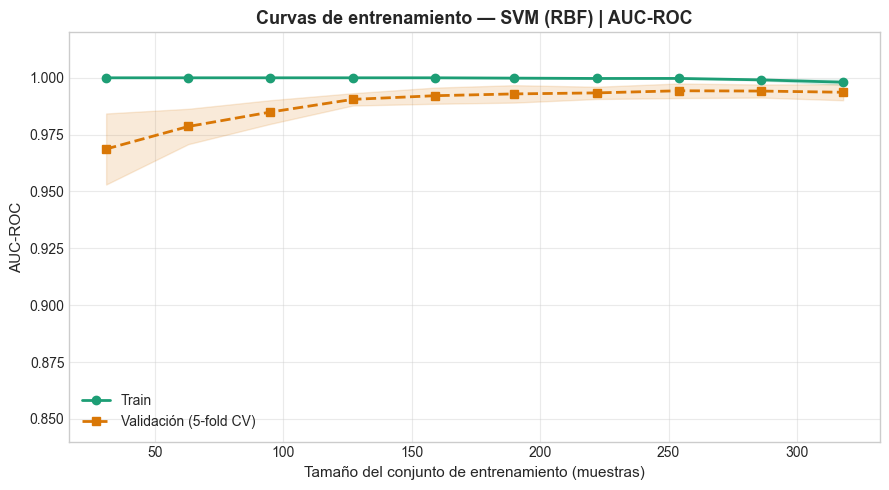

In [13]:
# F1-score
plot_learning_curve_metric(
    best_model,
    X_train_sc,
    y_train,
    scoring="f1",
    metric_name="F1-score",
    ylim=(0.84, 1.02)
)

# Recall para la clase maligna
recall_maligno = make_scorer(recall_score, pos_label=1)

plot_learning_curve_metric(
    best_model,
    X_train_sc,
    y_train,
    scoring=recall_maligno,
    metric_name="Recall (Maligno)",
    ylim=(0.84, 1.02)
)

# AUC-ROC
plot_learning_curve_metric(
    best_model,
    X_train_sc,
    y_train,
    scoring="roc_auc",
    metric_name="AUC-ROC",
    ylim=(0.84, 1.02)
)

El modelo SVM presenta un desempeño elevado y estable en las tres métricas evaluadas. Las curvas de validación aumentan conforme crece el número de muestras y se acercan progresivamente a las curvas de entrenamiento, lo que evidencia una buena capacidad de generalización.

Aunque existe una ligera diferencia entre entrenamiento y validación en Recall y F1-score, esta no parece indicar un sobreajuste severo. Además, el AUC cercano a 1.00 confirma que el modelo separa adecuadamente los tumores benignos y malignos.

Por tanto, el modelo SVM puede considerarse una alternativa sólida en la detección de tumores malignos.

Realicemos la matriz de confusión para el modelo SVM y así observar de manera un poco más detallada cómo se comporta y/o clasifica el modelo.


── Evaluación final en Test — SVM (RBF) ──
              precision    recall  f1-score   support

     Benigno       0.96      1.00      0.98        54
     Maligno       1.00      0.94      0.97        32

    accuracy                           0.98        86
   macro avg       0.98      0.97      0.97        86
weighted avg       0.98      0.98      0.98        86



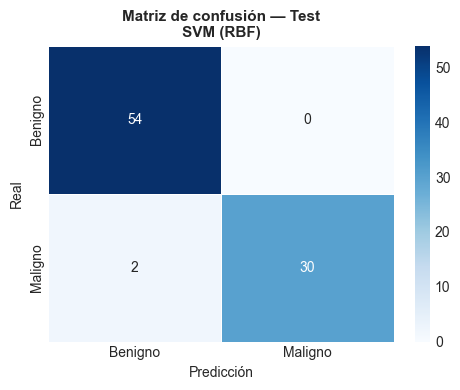

In [14]:
print(f"\n── Evaluación final en Test — {best_name} ──")
y_pred_test = best_model.predict(X_test_sc)
print(classification_report(y_test, y_pred_test, target_names=["Benigno", "Maligno"]))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_test)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Benigno", "Maligno"],
    yticklabels=["Benigno", "Maligno"],
    ax=ax, linewidths=0.5
)
ax.set_title(f"Matriz de confusión — Test\n{best_name}", fontsize=11, fontweight="bold")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

A pesar del excelente desempeño general del modelo, los 2 falsos negativos representan el principal punto de atención, ya que en este contexto es preferible reducir al máximo la probabilidad de clasificar un tumor maligno como benigno.

Por esta razón, aunque el modelo es bastante sólido y el Recall para la clase maligna es alto, con un valor de 0.94, estos errores deben analizarse cuidadosamente debido a su importancia clínica.

Veamos ahora las matrices de confusión para todos los modelos, de forma que podamos observar el comportamiento de ellos y de esta forma determinar cuál de ellos conviene más clinicamente hablando.

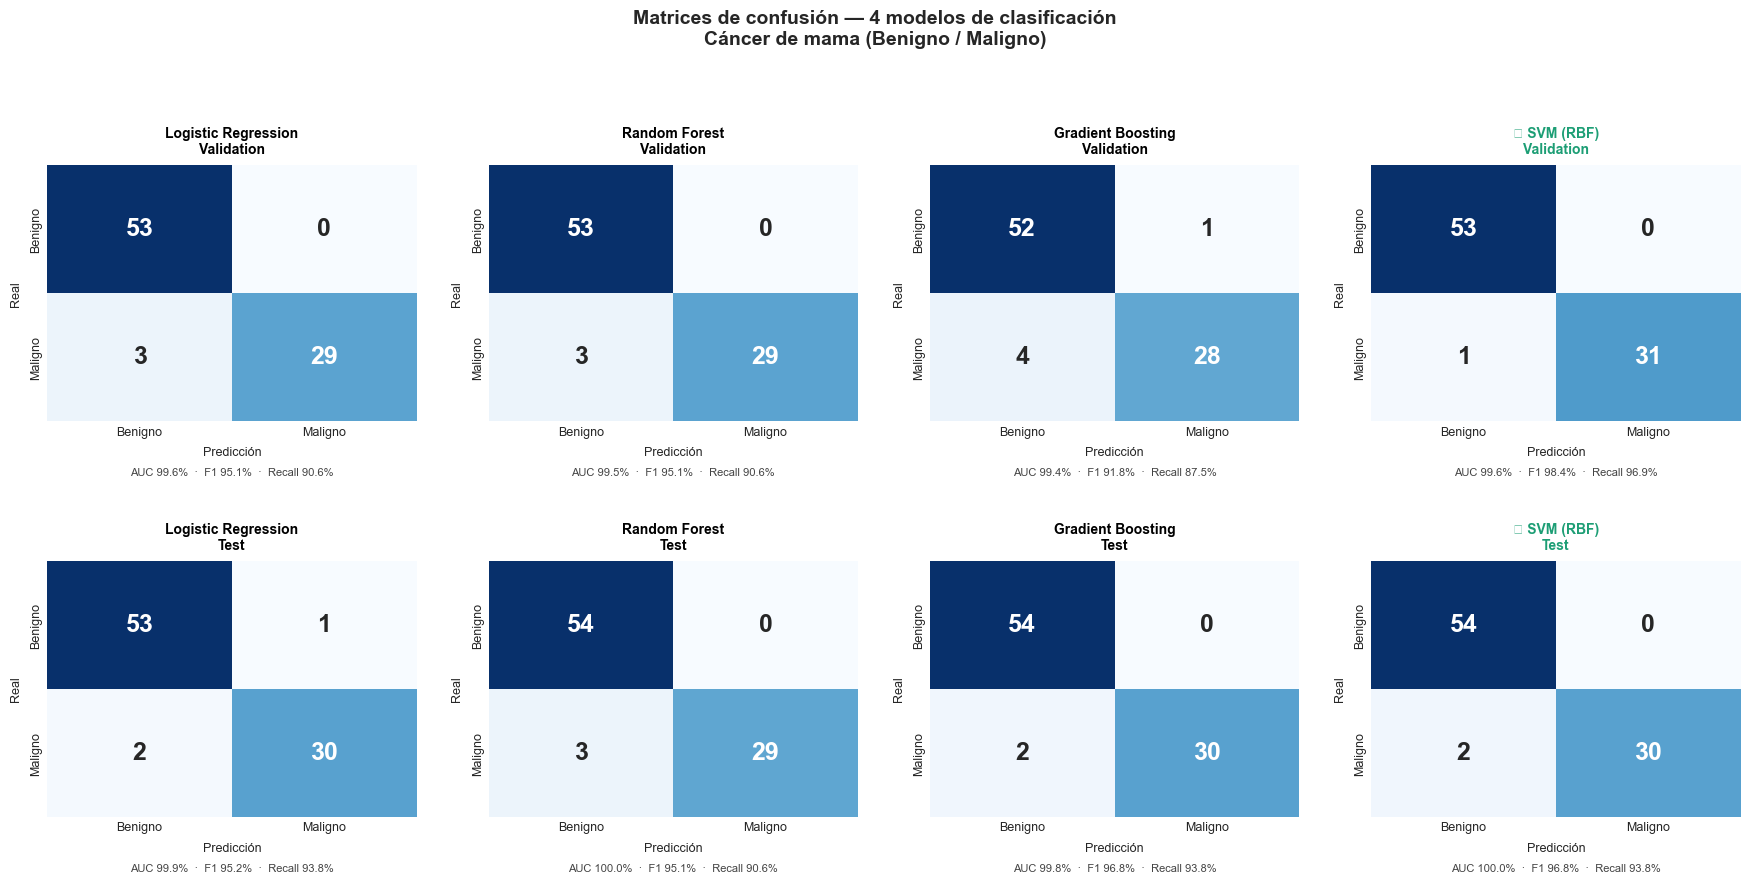

In [15]:
LABELS = ["Benigno", "Maligno"]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle(
    "Matrices de confusión — 4 modelos de clasificación\nCáncer de mama (Benigno / Maligno)",
    fontsize=14, fontweight="bold", y=1.01
)

for col_idx, name in enumerate(results.keys()):
    for row_idx, split in enumerate(["val", "test"]):

        ax = axes[row_idx, col_idx]

        if split == "val":
            cm_array = confusion_matrix(y_val,  results[name]["model"].predict(X_val_sc))
        else:
            cm_array = confusion_matrix(y_test, results[name]["model"].predict(X_test_sc))

        sns.heatmap(
            cm_array,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=LABELS,
            yticklabels=LABELS,
            ax=ax,
            linewidths=0,
            annot_kws={"size": 18, "weight": "bold"},
            cbar=False,
        )

        ax.set_xlabel("Predicción", fontsize=9, labelpad=6)
        ax.set_ylabel("Real",       fontsize=9, labelpad=6)
        ax.tick_params(axis="both", labelsize=9, length=0)
        ax.set_xticklabels(LABELS, fontsize=9)
        ax.set_yticklabels(LABELS, fontsize=9, rotation=90, va="center")

        # Título: nombre del modelo + split
        split_label = "Validation" if split == "val" else "Test"
        is_best     = (name == best_name)
        titulo      = f"{'★ ' if is_best else ''}{name}\n{split_label}"
        color_titulo = "#1D9E75" if is_best else "black"
        ax.set_title(titulo, fontsize=10, fontweight="bold",
                     pad=8, color=color_titulo)

        # Métricas debajo
        auc = results[name]["auc"] if split == "val" else roc_auc_score(
            y_test, results[name]["model"].predict_proba(X_test_sc)[:, 1]
        )
        f1_v = results[name]["f1"] if split == "val" else f1_score(
            y_test, results[name]["model"].predict(X_test_sc)
        )
        rec_v = results[name]["recall"] if split == "val" else classification_report(
            y_test, results[name]["model"].predict(X_test_sc), output_dict=True
        )["1"]["recall"]

        ax.annotate(
            f"AUC {auc*100:.1f}%  ·  F1 {f1_v*100:.1f}%  ·  Recall {rec_v*100:.1f}%",
            xy=(0.5, -0.18), xycoords="axes fraction",
            ha="center", va="top", fontsize=8, color="#444444"
        )

        # Borde verde al mejor modelo
        for spine in ax.spines.values():
            spine.set_edgecolor("#1D9E75" if is_best else "#cccccc")
            spine.set_linewidth(2.0 if is_best else 0.5)

plt.tight_layout(pad=2.5)
plt.show()

En efecto, observamos que SVM tiene mejor desempeño, aunque no es perfecto (como es de esperarse, pues ningún modelo suele serlo).

Los cuatro modelos evaluados muestran una capacidad discriminativa excelente (AUC > 0.99) para clasificar tumores de mama como malignos o benignos. Las curvas ROC se aproximan rápidamente a la esquina superior izquierda del gráfico, indicando que a umbrales bajos es posible detectar la mayoría de casos malignos con una tasa de falsos positivos mínima. La consistencia entre los resultados de validation y test confirma que los modelos generalizan bien y no presentan sobreajuste.